# Практическая работа №2
## «Исследование данных на Python. Обработка выбросов. Визуальный EDA»

**Датасет:** `Dataset1.csv` — сведения о фильмах (IMDb)

**План работы:**
1. Загрузка CPI и преобразование стоимостей в реальные доллары 2016 г.
2. Обработка выбросов (IQR capping)
3. Визуальный EDA — ответы на 10 вопросов

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from bs4 import BeautifulSoup
import requests
import warnings

warnings.filterwarnings('ignore')
plt.rcParams['figure.figsize'] = (10, 6)

---
## Часть 1. Загрузка CPI и преобразование стоимостей

### 1.1. Сбор данных CPI (Consumer Price Index)

Источник: [usinflationcalculator.com](https://www.usinflationcalculator.com/inflation/consumer-price-index-and-annual-percent-changes-from-1913-to-2008/)

Загружаем таблицу CPI за 1913–2016 гг. и сохраняем в CSV-файл.

In [2]:
SURNAME = 'Temerbalinov'

url = 'https://www.usinflationcalculator.com/inflation/consumer-price-index-and-annual-percent-changes-from-1913-to-2008/'
headers = {
    'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36'
}

r = requests.get(url, headers=headers, timeout=15)
soup = BeautifulSoup(r.text, 'html.parser')

table = soup.find('table')
# Исправление бага: table.tbody может быть None — используем find_all('tr') напрямую
rows = table.find_all('tr')

years = []
cpis = []

for row in rows:
    cells = row.find_all('td')
    if len(cells) > 13:
        year_text = cells[0].get_text().strip()
        cpi_text = cells[13].get_text().strip()
        try:
            year_val = int(year_text)
            cpi_val = float(cpi_text)
            if 1913 <= year_val <= 2016:
                years.append(year_val)
                cpis.append(cpi_val)
        except ValueError:
            continue

cpi_table = pd.DataFrame({
    'year': years,
    'avg_cpi': cpis
})

cpi_filename = f'Practice2_{SURNAME}_CPI.csv'
cpi_table.to_csv(cpi_filename, index=False)

n_rows = len(cpi_table)
year_min = int(cpi_table['year'].min())
year_max = int(cpi_table['year'].max())
print(f'Таблица CPI сохранена: {cpi_filename}')
print(f'Загружено записей: {n_rows}, диапазон лет: {year_min}–{year_max}')
cpi_table.head()

Таблица CPI сохранена: Practice2_Temerbalinov_CPI.csv
Загружено записей: 104, диапазон лет: 1913–2016


,year,avg_cpi
0,1913,9.9
1,1914,10.0
2,1915,10.1
3,1916,10.9
4,1917,12.8


In [3]:
def get_real_value(nominal_amt, old_cpi, new_cpi):
    """Перевод номинальных долларов в реальные доллары заданного года.
    Формула: real = nominal * new_cpi / old_cpi
    """
    return (nominal_amt * new_cpi) / old_cpi

# CPI 2016 — базовый год для сравнения
CPI_2016 = float(cpi_table[cpi_table['year'] == 2016]['avg_cpi'].values[0])
print(f'CPI 2016: {CPI_2016}')

CPI 2016: 240.007


### 1.2. Загрузка датасета

In [4]:
data = pd.read_csv('Dataset1.csv')
# Убираем лишние пробелы в именах столбцов (баг исходного CSV)
data.columns = data.columns.str.strip()
print(f'Размер датасета: {data.shape}')

Размер датасета: (5043, 28)


### 1.3. Предобработка данных

#### 1.3.1. Первичный осмотр

In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5043 entries, 0 to 5042
Data columns (total 28 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   color                      5025 non-null   object 
 1   Director_Name              4872 non-null   object 
 2   num_Critic_for_reviews     4927 non-null   float64
 3   duration                   4959 non-null   float64
 4   director_Facebook_likes    4872 non-null   float64
 5   actor_3_Facebook_likes     4953 non-null   float64
 6   actor_2_name               4963 non-null   object 
 7   Actor_1_Facebook_likes     4968 non-null   float64
 8   gross                      4104 non-null   float64
 9   genres                     4974 non-null   object 
 10  actor_1_name               4968 non-null   object 
 11  movie_Title                4974 non-null   object 
 12  num_voted_users            4974 non-null   float64
 13  cast_total_facebook_likes  4974 non-null   float

In [6]:
data.head(5)

,color,Director_Name,num_Critic_for_reviews,duration,director_Facebook_likes,actor_3_Facebook_likes,actor_2_name,Actor_1_Facebook_likes,gross,genres,...,num_user_for_reviews,language,country,content_rating,budget,title_year,actor_2_facebook_likes,imdb_score,aspect_ratio,movie_facebook_likes;
0,Color,James Cameron,723.0,178.0,0.0,855.0,Joel David Moore,1000.0,760505847.0,Action|Adventure|Fantasy|Sci-Fi,...,3054.0,English,USA,PG-13,237000000.0,2009.0,936.0,7.9,1.78,33000;
1,Colour,Gore Verbinski,302.0,169.0,563.0,1000.0,Orlando Bloom,40000.0,309404152.0,Action|Adventure|Fantasy,...,1238.0,English,USA,PG-13,300000000.0,2007.0,5000.0,7.1,2.35,0;
2,Colour,Sam Mendes,602.0,148.0,0.0,161.0,Rory Kinnear,11000.0,200074175.0,Action|Adventure|Thriller,...,994.0,English,UK,PG-13,245000000.0,2015.0,393.0,6.8,2.35,85000;
3,Color,Christopher Nolan,813.0,164.0,22000.0,23000.0,Christian Bale,27000.0,448130642.0,Action|Thriller,...,2701.0,English,USA,PG-13,250000000.0,2012.0,23000.0,8.5,2.35,164000;
4,NaN,Doug Walker,NaN,NaN,131.0,NaN,Rob Walker,131.0,NaN,Documentary,...,NaN,NaN,NaN,NaN,NaN,NaN,12.0,7.1,NaN,0;


Датасет содержит **28 столбцов** и **5043 строки**. Типы данных: `float64` (числовые признаки) и `str` (строковые). Видны пропуски в нескольких столбцах.

#### 1.3.2. Удаление полностью пустых строк

In [7]:
old_size = data.shape[0]
# Удаляем строки, где заполнен только 1 столбец из 28 (практически пустые)
data = data.drop(data[data.isna().sum(axis=1) == 27].index).reset_index(drop=True)
print(f'Удалено полностью пустых строк: {old_size - data.shape[0]}')
print(f'Размер датасета: {data.shape}')

Удалено полностью пустых строк: 69
Размер датасета: (4974, 28)


#### 1.3.3. Удаление дубликатов

In [8]:
# Полные дубликаты
print(f'Полных дубликатов: {data.duplicated().sum()}')
data = data.drop_duplicates(ignore_index=True)

# Дубликаты по названию фильма (один фильм — одна запись)
print(f'Дубликатов по movie_Title: {data.duplicated(subset="movie_Title").sum()}')
data = data.drop_duplicates(subset='movie_Title', ignore_index=True)
print(f'Размер после удаления дубликатов: {data.shape}')

Полных дубликатов: 44
Дубликатов по movie_Title: 80
Размер после удаления дубликатов: (4850, 28)


#### 1.3.4. Исправление столбца `movie_facebook_likes`

Столбец содержит точку с запятой в названии (`movie_facebook_likes;`) и в значениях (`"33000;"`). Очищаем оба.

In [9]:
data = data.rename(columns={'movie_facebook_likes;': 'movie_facebook_likes'})
data['movie_facebook_likes'] = (
    data['movie_facebook_likes'].astype(str).str.replace(';', '', regex=False).astype(float)
)
print('Столбец movie_facebook_likes очищен')
data['movie_facebook_likes'].head()

Столбец movie_facebook_likes очищен


0     33000.0
1         0.0
2     85000.0
3    164000.0
4         0.0
Name: movie_facebook_likes, dtype: float64

#### 1.3.5. Анализ пропусков

In [10]:
missing_pct = (data.isna().sum() / data.shape[0] * 100).sort_values(ascending=False)
print('Процент пропусков по столбцам:')
print(missing_pct[missing_pct > 0].to_string())

Процент пропусков по столбцам:
gross                      17.525773
budget                      9.752577
aspect_ratio                6.536082
content_rating              6.061856
plot_keywords               3.010309
title_year                  2.123711
Director_Name               2.061856
director_Facebook_likes     2.061856
num_Critic_for_reviews      0.948454
actor_3_name                0.432990
actor_3_Facebook_likes      0.432990
num_user_for_reviews        0.371134
color                       0.371134
duration                    0.309278
facenumber_in_poster        0.268041
language                    0.268041
actor_2_name                0.226804
actor_2_facebook_likes      0.226804
actor_1_name                0.123711
Actor_1_Facebook_likes      0.123711
country                     0.061856


#### 1.3.6. Заполнение пропусков

**Стратегия:**
- `title_year` — медиана (год нужен для CPI-конвертации)
- Имена актёров — `'unknown'`; лайки актёров — `0` (пропуски в одних и тех же строках)
- Числовые признаки (<2% пропусков) — медиана
- Категориальные признаки — мода
- `Director_Name`, `plot_keywords` — `'Unknown'`
- `director_Facebook_likes` — медиана по группе режиссёра, затем общей медианой
- `budget`, `gross` — медиана по группе года (учёт покупательной способности)

In [11]:
# title_year: медиана
data.fillna({'title_year': data['title_year'].median()}, inplace=True)
print(f'title_year пропусков: {data["title_year"].isna().sum()}')

title_year пропусков: 0


In [12]:
# Актёры: имена -> 'unknown', лайки -> 0
actor_name_cols = ['actor_3_name', 'actor_2_name', 'actor_1_name']
actor_likes_cols = ['actor_3_Facebook_likes', 'actor_2_facebook_likes', 'Actor_1_Facebook_likes']

for col in actor_likes_cols:
    data.fillna({col: 0}, inplace=True)
for col in actor_name_cols:
    data.fillna({col: 'unknown'}, inplace=True)

print('Актёры и лайки заполнены')

Актёры и лайки заполнены


In [13]:
# Числовые признаки: медиана
num_cols = ['num_Critic_for_reviews', 'num_user_for_reviews', 'duration', 'facenumber_in_poster']
for col in num_cols:
    data.fillna({col: data[col].median()}, inplace=True)
print('Числовые столбцы заполнены медианой')

Числовые столбцы заполнены медианой


In [14]:
# Категориальные признаки: мода
for col in ['color', 'language', 'country', 'aspect_ratio', 'content_rating']:
    data.fillna({col: data[col].mode()[0]}, inplace=True)
print('Категориальные столбцы заполнены модой')

Категориальные столбцы заполнены модой


In [15]:
# Режиссёр: лайки по группе, затем общей медианой; имя -> 'Unknown'
data['director_Facebook_likes'] = data.groupby('Director_Name')['director_Facebook_likes'].transform(
    lambda x: x.fillna(x.median())
)
data.fillna({'director_Facebook_likes': data['director_Facebook_likes'].median()}, inplace=True)
data.fillna({'Director_Name': 'Unknown'}, inplace=True)
data.fillna({'plot_keywords': 'unknown'}, inplace=True)
print('Режиссёр заполнен')

Режиссёр заполнен


In [16]:
# budget и gross: медиана по году, затем общей медианой
data['gross'] = data.groupby('title_year')['gross'].transform(lambda x: x.fillna(x.median()))
data['budget'] = data.groupby('title_year')['budget'].transform(lambda x: x.fillna(x.median()))
data.fillna({'gross': data['gross'].median()}, inplace=True)
data.fillna({'budget': data['budget'].median()}, inplace=True)
print(f'Пропусков после заполнения: {data.isna().sum().sum()}')

Пропусков после заполнения: 0


In [17]:
# Итоговая проверка
missing_final = (data.isna().sum() / data.shape[0] * 100).sort_values(ascending=False)
if missing_final.max() > 0:
    print('Остались пропуски:')
    print(missing_final[missing_final > 0])
else:
    print('Все пропуски заполнены. Размер датасета:', data.shape)

Все пропуски заполнены. Размер датасета: (4850, 28)


### 1.4. Перевод бюджета и кассовых сборов в реальные доллары 2016 г.

Для корректного сравнения фильмов разных лет применяем CPI-поправку:

$$\text{Реальная сумма} = \frac{\text{Номинальная сумма} \times \text{CPI}_{2016}}{\text{CPI}_{\text{год}}}$$

In [18]:
# Словарь year -> avg_cpi для быстрого поиска
cpi_dict = dict(zip(cpi_table['year'], cpi_table['avg_cpi']))
cpi_min_year = int(cpi_table['year'].min())
cpi_max_year = int(cpi_table['year'].max())

def get_year_cpi(year):
    """Возвращает CPI для года, ограничивая диапазоном таблицы."""
    year = max(cpi_min_year, min(cpi_max_year, int(year)))
    return cpi_dict.get(year, CPI_2016)

data['_cpi'] = data['title_year'].apply(get_year_cpi)
data['real_domestic_gross'] = data['gross'] * CPI_2016 / data['_cpi']
data['real_budget'] = data['budget'] * CPI_2016 / data['_cpi']
data = data.drop(columns=['_cpi'])

print('Столбцы real_domestic_gross и real_budget добавлены')
data[['movie_Title', 'title_year', 'budget', 'real_budget', 'gross', 'real_domestic_gross']].head()

Столбцы real_domestic_gross и real_budget добавлены


,movie_Title,title_year,budget,real_budget,gross,real_domestic_gross
0,Avatar,2009.0,237000000.0,2.651368e+08,760505847.0,8.507937e+08
1,Pirates of the Caribbean: At World's End,2007.0,300000000.0,3.473329e+08,309404152.0,3.582208e+08
2,Spectre,2015.0,245000000.0,2.480907e+08,200074175.0,2.025981e+08
3,The Dark Knight Rises,2012.0,250000000.0,2.613385e+08,448130642.0,4.684551e+08
4,Star Wars: Episode VII - The Force Awakens ...,2005.0,25000000.0,3.072286e+07,20205006.5,2.483023e+07


### 1.5. Расчёт прибыли и ROI

- **profit** = `real_domestic_gross` − `real_budget`
- **ROI** (%) = `(profit − budget) / budget × 100`

In [19]:
profits = []
roi_vals = []

for _, row in data.iterrows():
    profit = row['real_domestic_gross'] - row['real_budget']
    budget = row['real_budget']
    num = profit - budget
    den = budget
    roi = (num / den) * 100 if den != 0 else 0
    profits.append(profit)
    roi_vals.append(roi)

data['profit'] = profits
data['roi'] = roi_vals

print('Столбцы profit и roi добавлены')
data[['movie_Title', 'real_budget', 'real_domestic_gross', 'profit', 'roi']].head()

Столбцы profit и roi добавлены


,movie_Title,real_budget,real_domestic_gross,profit,roi
0,Avatar,2.651368e+08,8.507937e+08,5.856569e+08,120.888543
1,Pirates of the Caribbean: At World's End,3.473329e+08,3.582208e+08,1.088790e+07,-96.865283
2,Spectre,2.480907e+08,2.025981e+08,-4.549257e+07,-118.337071
3,The Dark Knight Rises,2.613385e+08,4.684551e+08,2.071167e+08,-20.747743
4,Star Wars: Episode VII - The Force Awakens ...,3.072286e+07,2.483023e+07,-5.892637e+06,-119.179974


---
## Часть 2. Обработка выбросов

Используем метод **межквартильного размаха (IQR)** для обнаружения выбросов и метод **ограничения (capping/winsorization)** для их обработки.

- **Нижняя граница:** Q1 − 1.5 × IQR
- **Верхняя граница:** Q3 + 1.5 × IQR

Выбросы заменяются граничными значениями (не удаляются), чтобы сохранить объём данных.

In [20]:
outlier_cols = ['real_budget', 'real_domestic_gross', 'duration', 'imdb_score', 'num_voted_users', 'profit']

print('Выбросы (IQR-метод) до обработки:')
for col in outlier_cols:
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n = ((data[col] < lower) | (data[col] > upper)).sum()
    pct = n / len(data) * 100
    print(f'  {col}: {n} выбросов ({pct:.1f}%)')

Выбросы (IQR-метод) до обработки:
  real_budget: 368 выбросов (7.6%)
  real_domestic_gross: 466 выбросов (9.6%)
  duration: 231 выбросов (4.8%)
  imdb_score: 116 выбросов (2.4%)
  num_voted_users: 454 выбросов (9.4%)
  profit: 593 выбросов (12.2%)


In [21]:
# Ограничение (capping): заменяем выбросы граничными значениями IQR
for col in outlier_cols:
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    data[col] = data[col].clip(lower=lower, upper=upper)

print('Выбросы обработаны методом capping (ограничения)')
print(f'Размер датасета: {data.shape}')

Выбросы обработаны методом capping (ограничения)
Размер датасета: (4850, 32)


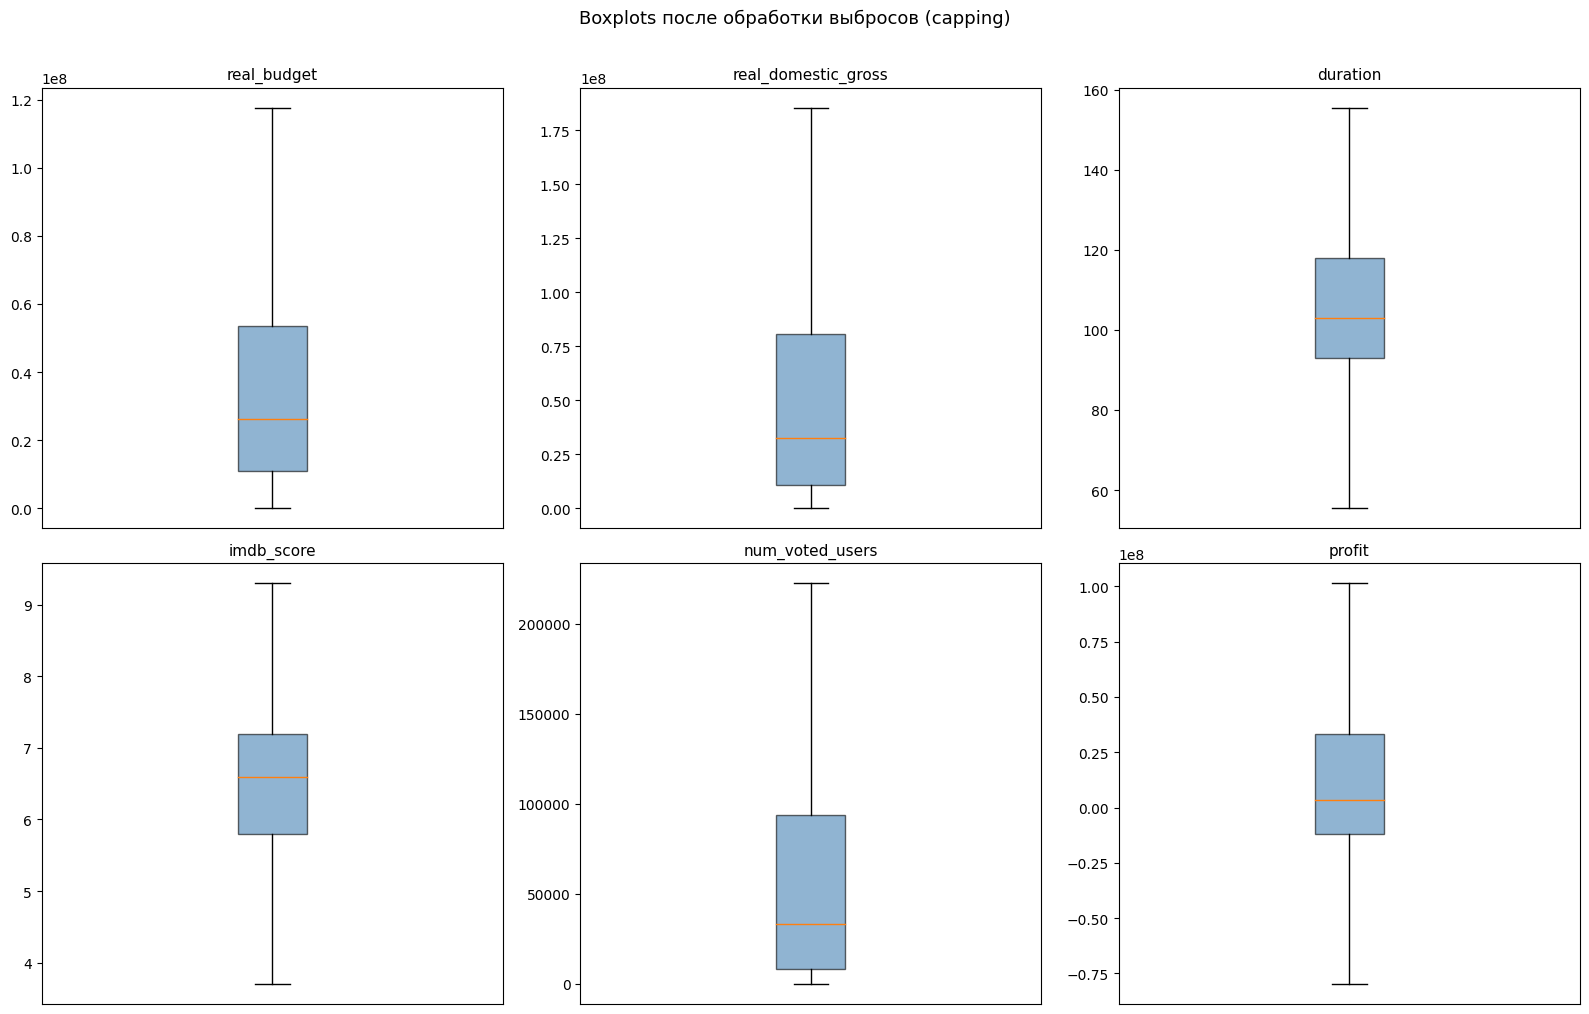

In [22]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(outlier_cols):
    axes[i].boxplot(data[col].dropna(), vert=True, patch_artist=True,
                    boxprops=dict(facecolor='steelblue', alpha=0.6))
    axes[i].set_title(col, fontsize=11)
    axes[i].set_xticks([])

plt.suptitle('Boxplots после обработки выбросов (capping)', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

---
## Часть 3. Визуальный EDA

Отвечаем на 10 вопросов с помощью графиков.

### Вопрос 1. Как распределены рейтинги фильмов (IMDb score)?

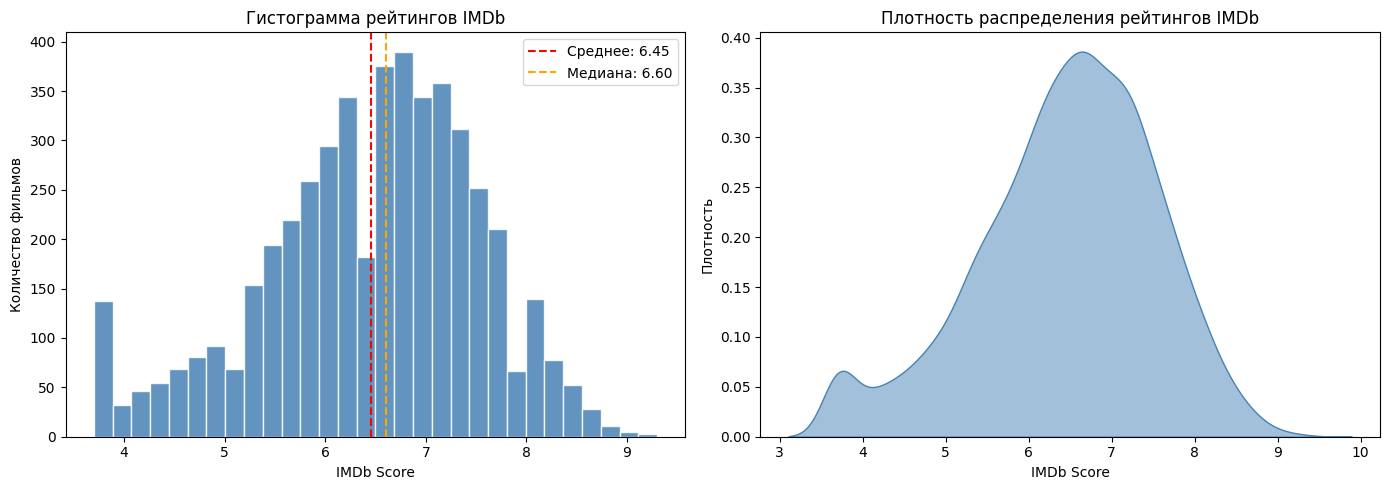

Среднее: 6.45 | Медиана: 6.60 | Ст. откл.: 1.08
Вывод: распределение рейтингов близко к нормальному с небольшим смещением влево. Большинство фильмов имеют оценку 6–7 баллов.


In [23]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Гистограмма
axes[0].hist(data['imdb_score'], bins=30, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].axvline(data['imdb_score'].mean(), color='red', linestyle='--', linewidth=1.5,
                label=f'Среднее: {data["imdb_score"].mean():.2f}')
axes[0].axvline(data['imdb_score'].median(), color='orange', linestyle='--', linewidth=1.5,
                label=f'Медиана: {data["imdb_score"].median():.2f}')
axes[0].set_title('Гистограмма рейтингов IMDb')
axes[0].set_xlabel('IMDb Score')
axes[0].set_ylabel('Количество фильмов')
axes[0].legend()

# KDE
sns.kdeplot(data['imdb_score'], ax=axes[1], fill=True, color='steelblue', alpha=0.5)
axes[1].set_title('Плотность распределения рейтингов IMDb')
axes[1].set_xlabel('IMDb Score')
axes[1].set_ylabel('Плотность')

plt.tight_layout()
plt.show()

print(f'Среднее: {data["imdb_score"].mean():.2f} | Медиана: {data["imdb_score"].median():.2f} | '
      f'Ст. откл.: {data["imdb_score"].std():.2f}')
print('Вывод: распределение рейтингов близко к нормальному с небольшим смещением влево. '
      'Большинство фильмов имеют оценку 6–7 баллов.')

### Вопрос 2. Существует ли зависимость между бюджетом фильма и его кассовыми сборами?

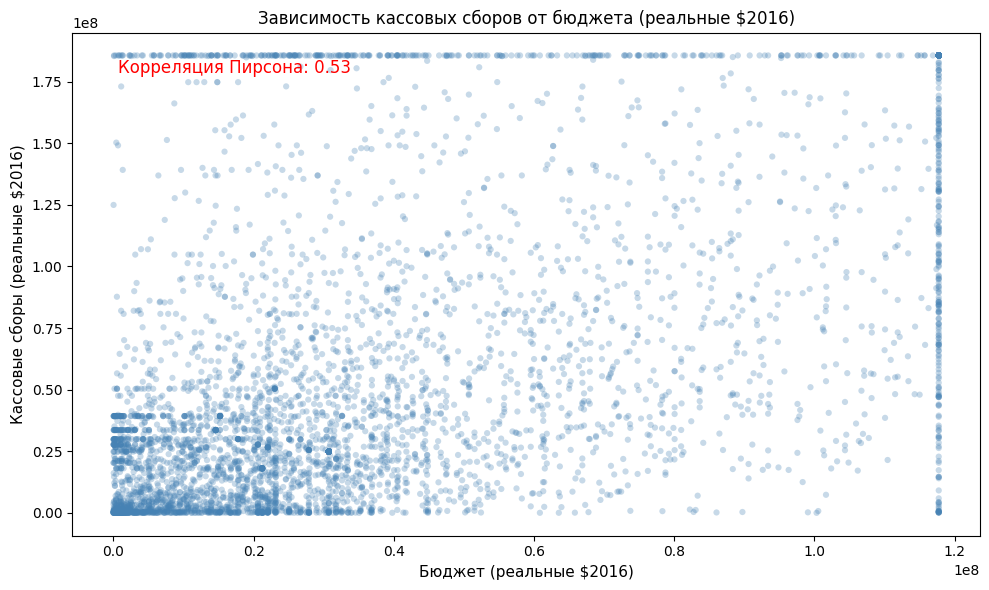

Коэффициент корреляции Пирсона: 0.528


In [33]:
plt.figure(figsize=(10, 6))
plt.scatter(data['real_budget'], data['real_domestic_gross'],
            alpha=0.3, color='steelblue', edgecolors='none', s=20)
plt.xlabel('Бюджет (реальные $2016)', fontsize=11)
plt.ylabel('Кассовые сборы (реальные $2016)', fontsize=11)
plt.title('Зависимость кассовых сборов от бюджета (реальные $2016)', fontsize=12)

corr = data[['real_budget', 'real_domestic_gross']].corr().iloc[0, 1]
plt.annotate(f'Корреляция Пирсона: {corr:.2f}', xy=(0.05, 0.92),
             xycoords='axes fraction', fontsize=12, color='red')

plt.tight_layout()
plt.show()

print(f'Коэффициент корреляции Пирсона: {corr:.3f}')

Вывод: наблюдается умеренная положительная корреляция — фильмы с большим бюджетом в среднем собирают больше кассовых сборов, но корреляция не абсолютная.

### Вопрос 3. Какие жанры встречаются чаще всего?

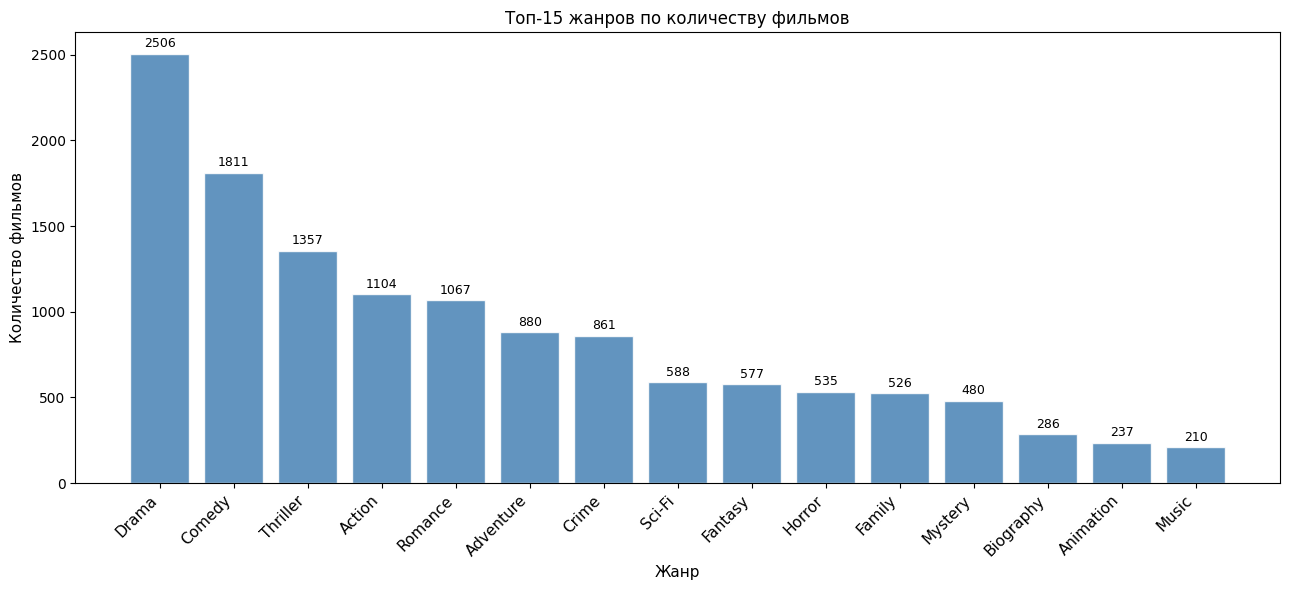

Самый популярный жанр: Drama (2506 фильмов)


In [34]:
genres_series = data['genres'].dropna().str.split('|').explode()
top_genres = genres_series.value_counts().head(15)

plt.figure(figsize=(13, 6))
bars = plt.bar(range(len(top_genres)), top_genres.values, color='steelblue', edgecolor='white', alpha=0.85)
plt.xticks(range(len(top_genres)), top_genres.index, rotation=45, ha='right', fontsize=11)
plt.xlabel('Жанр', fontsize=11)
plt.ylabel('Количество фильмов', fontsize=11)
plt.title('Топ-15 жанров по количеству фильмов', fontsize=12)
for bar, val in zip(bars, top_genres.values):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 20,
             str(val), ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()

print(f'Самый популярный жанр: {top_genres.index[0]} ({top_genres.values[0]} фильмов)')

Вывод: Drama и Comedy встречаются наиболее часто, далее — Thriller, Romance и Action.

### Вопрос 4. Влияет ли количество проголосовавших пользователей на итоговый рейтинг?

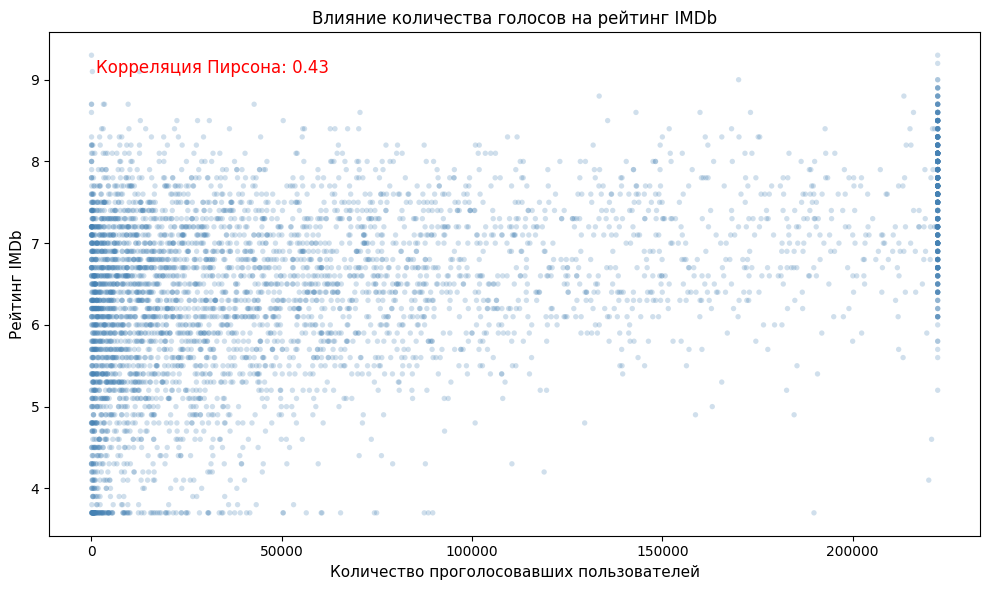

Коэффициент корреляции Пирсона: 0.433


In [35]:
plt.figure(figsize=(10, 6))
plt.scatter(data['num_voted_users'], data['imdb_score'],
            alpha=0.25, color='steelblue', edgecolors='none', s=15)
plt.xlabel('Количество проголосовавших пользователей', fontsize=11)
plt.ylabel('Рейтинг IMDb', fontsize=11)
plt.title('Влияние количества голосов на рейтинг IMDb', fontsize=12)

corr = data[['num_voted_users', 'imdb_score']].corr().iloc[0, 1]
plt.annotate(f'Корреляция Пирсона: {corr:.2f}', xy=(0.05, 0.92),
             xycoords='axes fraction', fontsize=12, color='red')

plt.tight_layout()
plt.show()

print(f'Коэффициент корреляции Пирсона: {corr:.3f}')

Вывод: умеренная положительная корреляция. Фильмы с большим числом голосов как правило имеют более высокий рейтинг — популярные фильмы привлекают больше внимания.

### Вопрос 5. Есть ли связь между суммарными лайками актёров в Facebook и рейтингом фильма?

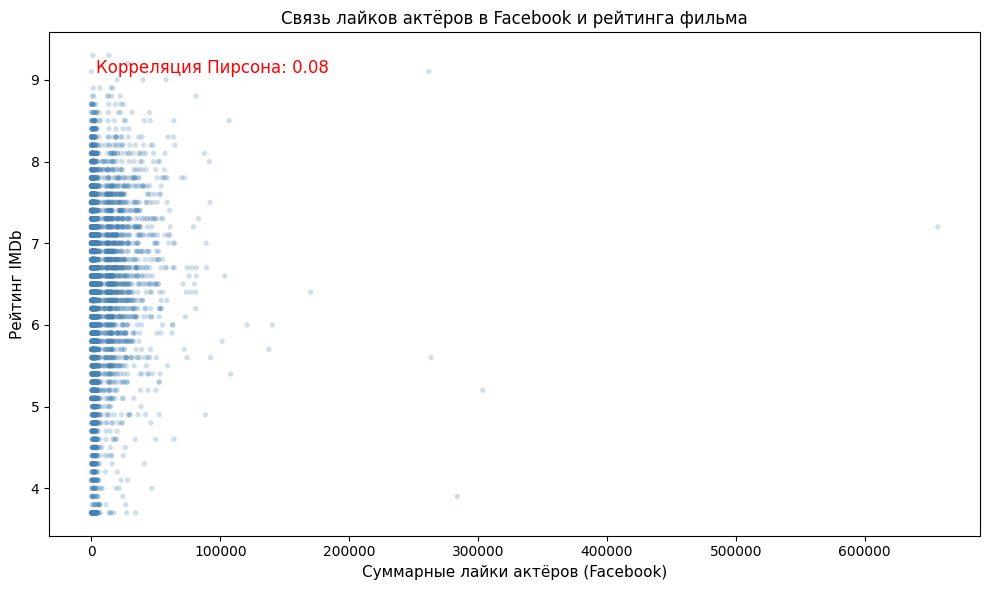

Коэффициент корреляции Пирсона: 0.084


In [36]:
plt.figure(figsize=(10, 6))
plt.scatter(data['cast_total_facebook_likes'], data['imdb_score'],
            alpha=0.25, color='steelblue', edgecolors='none', s=15)
plt.xlabel('Суммарные лайки актёров (Facebook)', fontsize=11)
plt.ylabel('Рейтинг IMDb', fontsize=11)
plt.title('Связь лайков актёров в Facebook и рейтинга фильма', fontsize=12)

corr = data[['cast_total_facebook_likes', 'imdb_score']].corr().iloc[0, 1]
plt.annotate(f'Корреляция Пирсона: {corr:.2f}', xy=(0.05, 0.92),
             xycoords='axes fraction', fontsize=12, color='red')

plt.tight_layout()
plt.show()

print(f'Коэффициент корреляции Пирсона: {corr:.3f}')

Вывод: корреляция слабая. Количество лайков актёров в Facebook почти не влияет на итоговый рейтинг фильма.

### Вопрос 6. Как изменялся средний бюджет фильмов по годам?

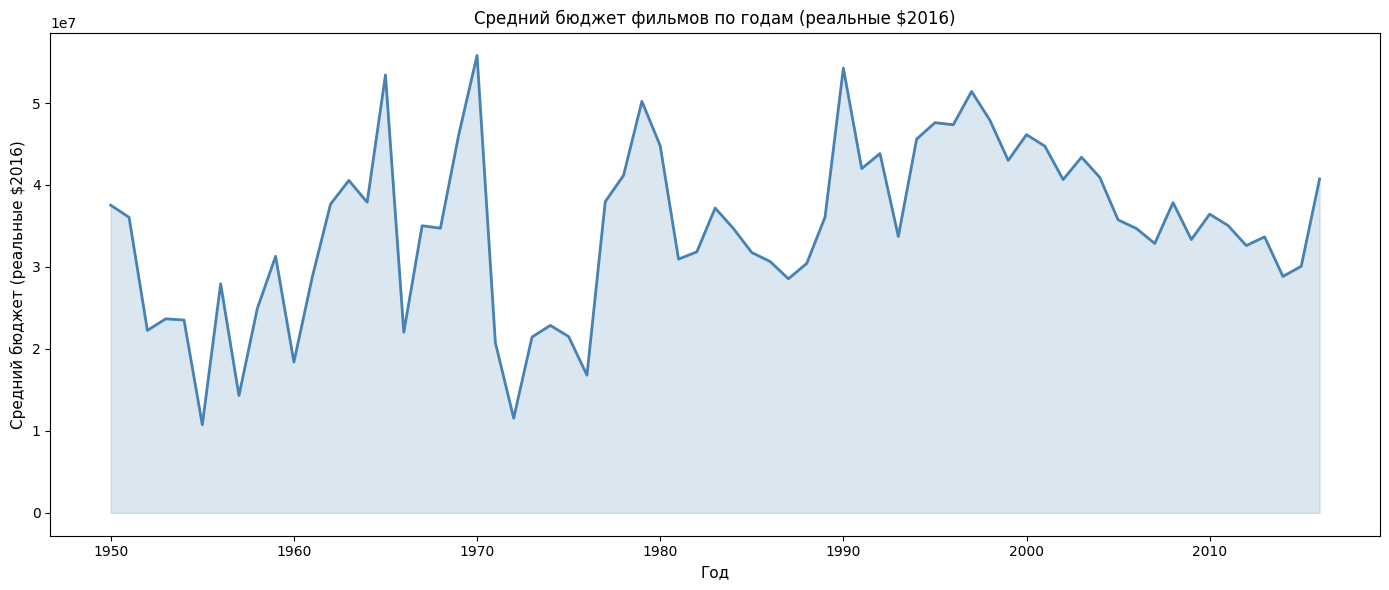

In [37]:
budget_by_year = data.groupby('title_year')['real_budget'].mean().reset_index()
budget_by_year = budget_by_year[budget_by_year['title_year'] >= 1950]  # фильтр: с 1950 г. достаточно данных

plt.figure(figsize=(14, 6))
plt.plot(budget_by_year['title_year'], budget_by_year['real_budget'],
         color='steelblue', linewidth=2)
plt.fill_between(budget_by_year['title_year'], budget_by_year['real_budget'],
                 alpha=0.2, color='steelblue')
plt.xlabel('Год', fontsize=11)
plt.ylabel('Средний бюджет (реальные $2016)', fontsize=11)
plt.title('Средний бюджет фильмов по годам (реальные $2016)', fontsize=12)
plt.tight_layout()
plt.show()

Вывод: средний бюджет фильмов постепенно рос с 1950-х гг. до начала 2000-х, после чего стабилизировался.

### Вопрос 7. Какие страны лидируют по количеству произведённых фильмов?

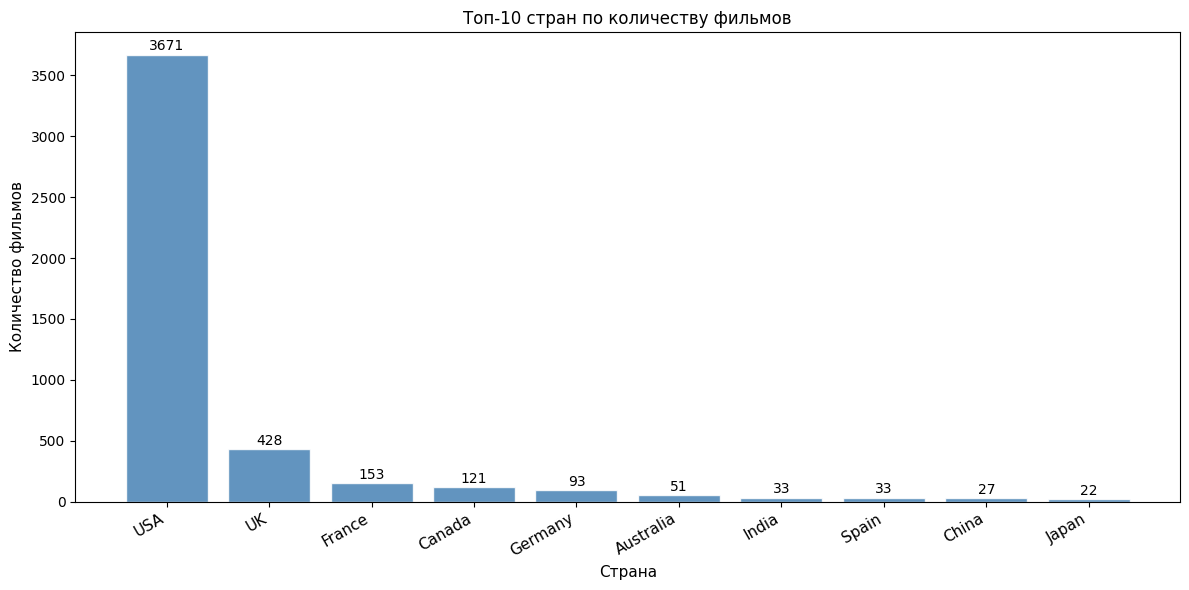

Лидер: USA (3671 фильмов)


In [38]:
top_countries = data['country'].value_counts().head(10)

plt.figure(figsize=(12, 6))
bars = plt.bar(range(len(top_countries)), top_countries.values,
               color='steelblue', edgecolor='white', alpha=0.85)
plt.xticks(range(len(top_countries)), top_countries.index, rotation=30, ha='right', fontsize=11)
plt.xlabel('Страна', fontsize=11)
plt.ylabel('Количество фильмов', fontsize=11)
plt.title('Топ-10 стран по количеству фильмов', fontsize=12)
for bar, val in zip(bars, top_countries.values):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 10,
             str(val), ha='center', va='bottom', fontsize=10)
plt.tight_layout()
plt.show()

print(f'Лидер: {top_countries.index[0]} ({top_countries.values[0]} фильмов)')

Вывод: США значительно опережают все остальные страны по числу фильмов в датасете.

### Вопрос 8. Каково распределение длительности фильмов?

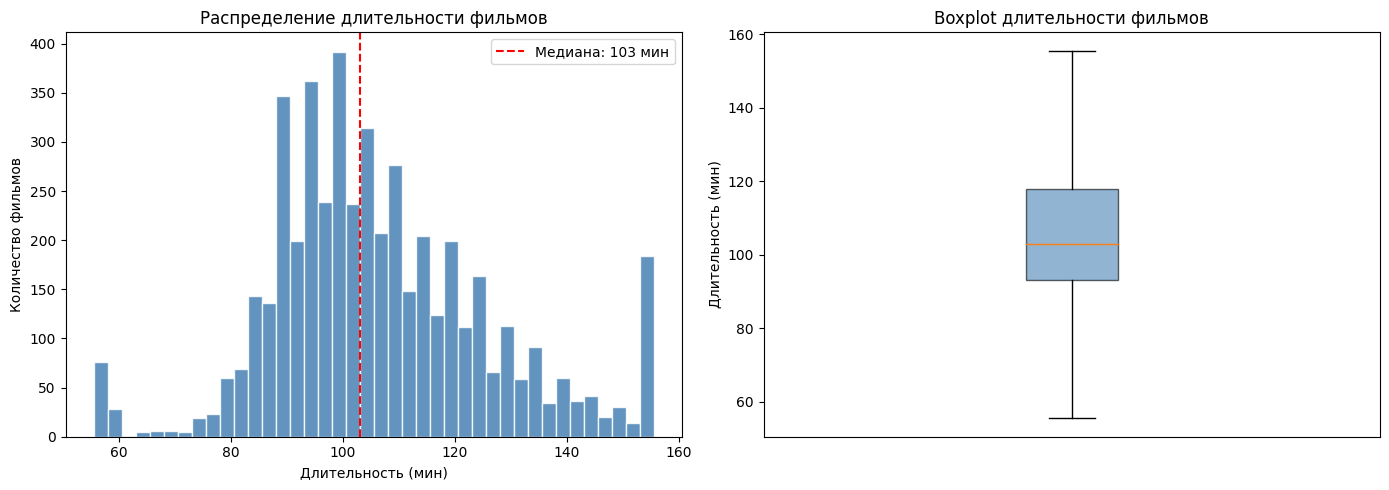

Средняя: 106 мин | Медиана: 103 мин | Ст. откл.: 20 мин


In [39]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Гистограмма
axes[0].hist(data['duration'], bins=40, color='steelblue', edgecolor='white', alpha=0.85)
med = data['duration'].median()
axes[0].axvline(med, color='red', linestyle='--', linewidth=1.5,
                label=f'Медиана: {med:.0f} мин')
axes[0].set_title('Распределение длительности фильмов')
axes[0].set_xlabel('Длительность (мин)')
axes[0].set_ylabel('Количество фильмов')
axes[0].legend()

# Boxplot
axes[1].boxplot(data['duration'].dropna(), vert=True, patch_artist=True,
                boxprops=dict(facecolor='steelblue', alpha=0.6))
axes[1].set_title('Boxplot длительности фильмов')
axes[1].set_ylabel('Длительность (мин)')
axes[1].set_xticks([])

plt.tight_layout()
plt.show()

print(f'Средняя: {data["duration"].mean():.0f} мин | Медиана: {data["duration"].median():.0f} мин | '
      f'Ст. откл.: {data["duration"].std():.0f} мин')

Вывод: большинство фильмов длятся 90–120 минут. Распределение слегка правоскошенное.

### Вопрос 9. Различаются ли кассовые сборы в зависимости от возрастного рейтинга?

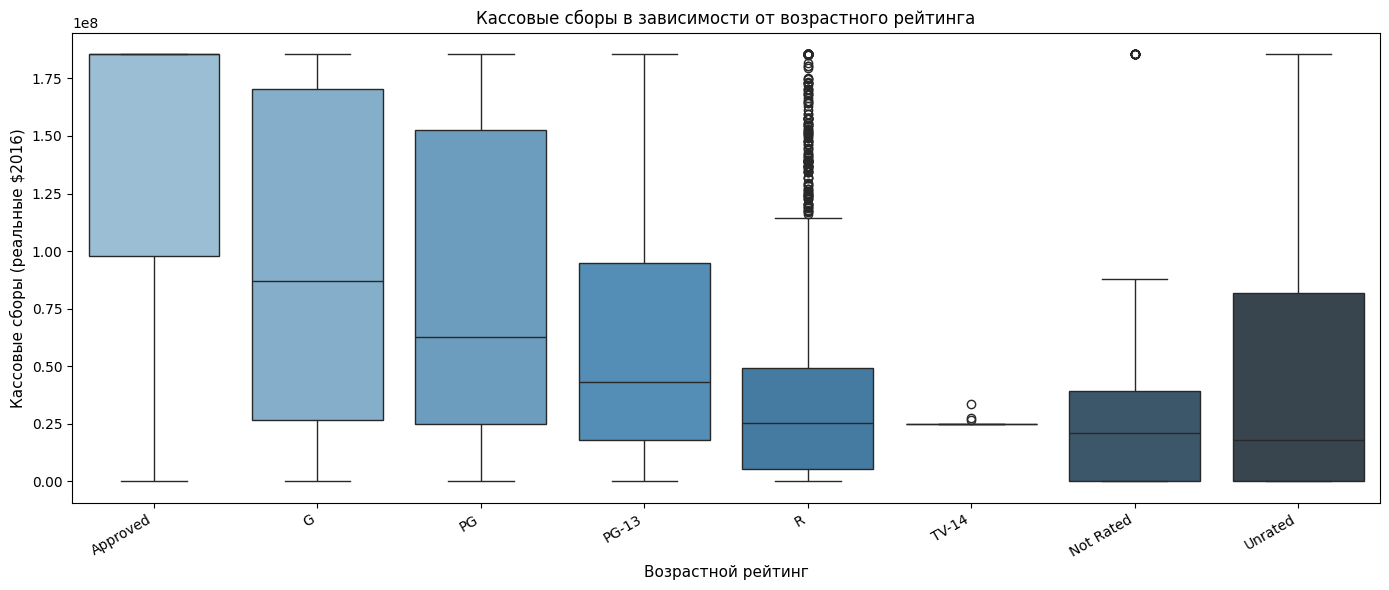

Медианные сборы по рейтингу (реальные $2016):
content_rating
Approved     $185,600,231
G             $87,176,868
PG            $62,673,430
PG-13         $43,129,840
R             $25,229,180
TV-14         $24,830,225
Not Rated     $21,077,792
Unrated       $17,886,126


In [40]:
# Оставляем только наиболее распространённые возрастные рейтинги
top_ratings = data['content_rating'].value_counts().head(8).index.tolist()
plot_data = data[data['content_rating'].isin(top_ratings)].copy()

# Упорядочиваем по медиане сборов
order = (plot_data.groupby('content_rating')['real_domestic_gross']
         .median().sort_values(ascending=False).index.tolist())

plt.figure(figsize=(14, 6))
sns.boxplot(data=plot_data, x='content_rating', y='real_domestic_gross',
            order=order, palette='Blues_d')
plt.xlabel('Возрастной рейтинг', fontsize=11)
plt.ylabel('Кассовые сборы (реальные $2016)', fontsize=11)
plt.title('Кассовые сборы в зависимости от возрастного рейтинга', fontsize=12)
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

medians = plot_data.groupby('content_rating')['real_domestic_gross'].median().reindex(order)
print('Медианные сборы по рейтингу (реальные $2016):')
print(medians.apply(lambda x: f'${x:,.0f}').to_string())

Вывод: фильмы рейтинга PG и PG-13 в среднем собирают больше, чем фильмы рейтинга R или NC-17.

### Вопрос 10. Кто из режиссёров снял больше всего фильмов в данной выборке?

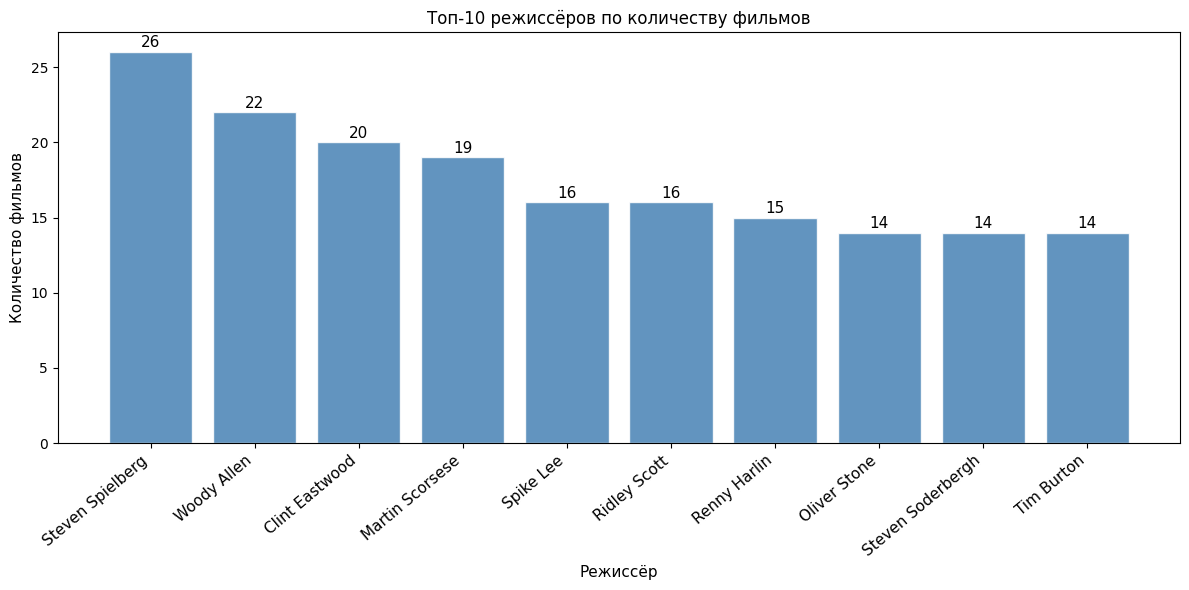

Режиссёр с наибольшим числом фильмов: Steven Spielberg (26 фильмов)


In [41]:
top_directors = (data[data['Director_Name'] != 'Unknown']['Director_Name']
                 .value_counts().head(10))

plt.figure(figsize=(12, 6))
bars = plt.bar(range(len(top_directors)), top_directors.values,
               color='steelblue', edgecolor='white', alpha=0.85)
plt.xticks(range(len(top_directors)), top_directors.index, rotation=40, ha='right', fontsize=11)
plt.xlabel('Режиссёр', fontsize=11)
plt.ylabel('Количество фильмов', fontsize=11)
plt.title('Топ-10 режиссёров по количеству фильмов', fontsize=12)
for bar, val in zip(bars, top_directors.values):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.1,
             str(val), ha='center', va='bottom', fontsize=11)
plt.tight_layout()
plt.show()

print(f'Режиссёр с наибольшим числом фильмов: {top_directors.index[0]} ({top_directors.values[0]} фильмов)')


Вывод: в топ-10 входят преимущественно режиссёры, специализирующиеся на жанровом кино.